In [34]:
import sys
sys.path.insert(0, '..')
from methods.graphs import *
# Importy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Pokus o UMAP (pokud není instalován, fallback na t-SNE)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP není instalován, budu používat t-SNE jako fallback")

In [ ]:

def plot_comparison(X_pca, X_kpca, X_umap, X_tsne, y):
    """Porovnání PCA, KPCA, UMAP a t-SNE v jednom grafu"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # PCA
    scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)
    axes[0, 0].set_title('PCA (Linear)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Component 1')
    axes[0, 1].set_ylabel('Component 2')
    plt.colorbar(scatter1, ax=axes[0, 0], label='Digit')
    
    # KPCA
    scatter2 = axes[0, 1].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)
    axes[0, 1].set_title('Kernel PCA (RBF)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Component 1')
    axes[0, 1].set_ylabel('Component 2')
    plt.colorbar(scatter2, ax=axes[0, 1], label='Digit')
    
    # UMAP
    scatter3 = axes[1, 0].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)
    axes[1, 0].set_title('UMAP (Non-linear)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Dimension 1')
    axes[1, 0].set_ylabel('Dimension 2')
    plt.colorbar(scatter3, ax=axes[1, 0], label='Digit')

    # t-SNE
    scatter4 = axes[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6, s=30)
    axes[1, 1].set_title('t-SNE (Non-linear)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Dimension 1')
    axes[1, 1].set_ylabel('Dimension 2')
    plt.colorbar(scatter4, ax=axes[1, 1], label='Digit')
    plt.tight_layout()
    plt.show()


def plot_silhouette_scores(sil_pca, sil_kpca, sil_umap, sil_tsne):
    """Vykreslení porovnání Silhouette skórů pro všechny 4 metody"""
    results_df = pd.DataFrame({
        'Metoda': ['PCA', 'KPCA', 'UMAP', 't-SNE'],
        'Silhouette Score': [sil_pca, sil_kpca, sil_umap, sil_tsne],
        'Typ': ['Lineární', 'Kernelová', 'Nelineární', 'Nelineární']
    })
    
    print("Silhouette Score (higher is better):")
    print(f"  PCA:   {sil_pca:.4f}")
    print(f"  KPCA:  {sil_kpca:.4f}")
    print(f"  UMAP:  {sil_umap:.4f}")
    print(f"  t-SNE: {sil_tsne:.4f}\n")
    print("Souhrnná tabulka:")
    print(results_df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(results_df['Metoda'], results_df['Silhouette Score'], 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
    ax.set_title('Porovnání metod redukce dimenzionality', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(results_df['Silhouette Score']) * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def plot_mnist_samples(X_data, y, num_samples=50):
    """Zobrazení vzorků z MNIST datasetu (28x28)"""
    rows = num_samples // 10
    fig, axes = plt.subplots(rows, 10, figsize=(12, 6))
    
    for i in range(num_samples):
        row = i // 10
        col = i % 10
        ax = axes[row, col] if rows > 1 else axes[col]
        # Reshape z (784,) na (28, 28)
        img = X_data[i].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{y[i]}', fontsize=10)
        ax.axis('off')
    
    plt.suptitle('Vzorky z MNIST dataset (28×28 číslic)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("✓ Všechny grafovací funkce načteny")

✓ Všechny grafovací funkce načteny


In [36]:
# ============================================================================
# NAČTENÍ A PŘÍPRAVA DATASETU - MNIST 28x28
# ============================================================================

from tensorflow.keras.datasets import mnist

# Načteme MNIST dataset (28x28 obrázky)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Vezmi jen část dat pro rychlejší výpočet
n_samples = 30000
X = np.vstack([X_train[:30000], X_test[:3000]])  # 5500 vzorků
y = np.hstack([y_train[:30000], y_test[:3000]])

# Reshape z (N, 28, 28) na (N, 784)
X = X.reshape(X.shape[0], -1).astype('float32')

print(f"Dataset shape: {X.shape}")
print(f"Počet vzorků: {X.shape[0]}, Počet features: {X.shape[1]}")
print(f"Unikátní třídy: {np.unique(y)}")
print(f"Obrázky jsou: 28x28 (784 pixelů)")

# Normalizace dat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData připravena a normalizována!")

Dataset shape: (33000, 784)
Počet vzorků: 33000, Počet features: 784
Unikátní třídy: [0 1 2 3 4 5 6 7 8 9]
Obrázky jsou: 28x28 (784 pixelů)

Data připravena a normalizována!


                         ANALÝZA DATASETU - MNIST 28x28                         


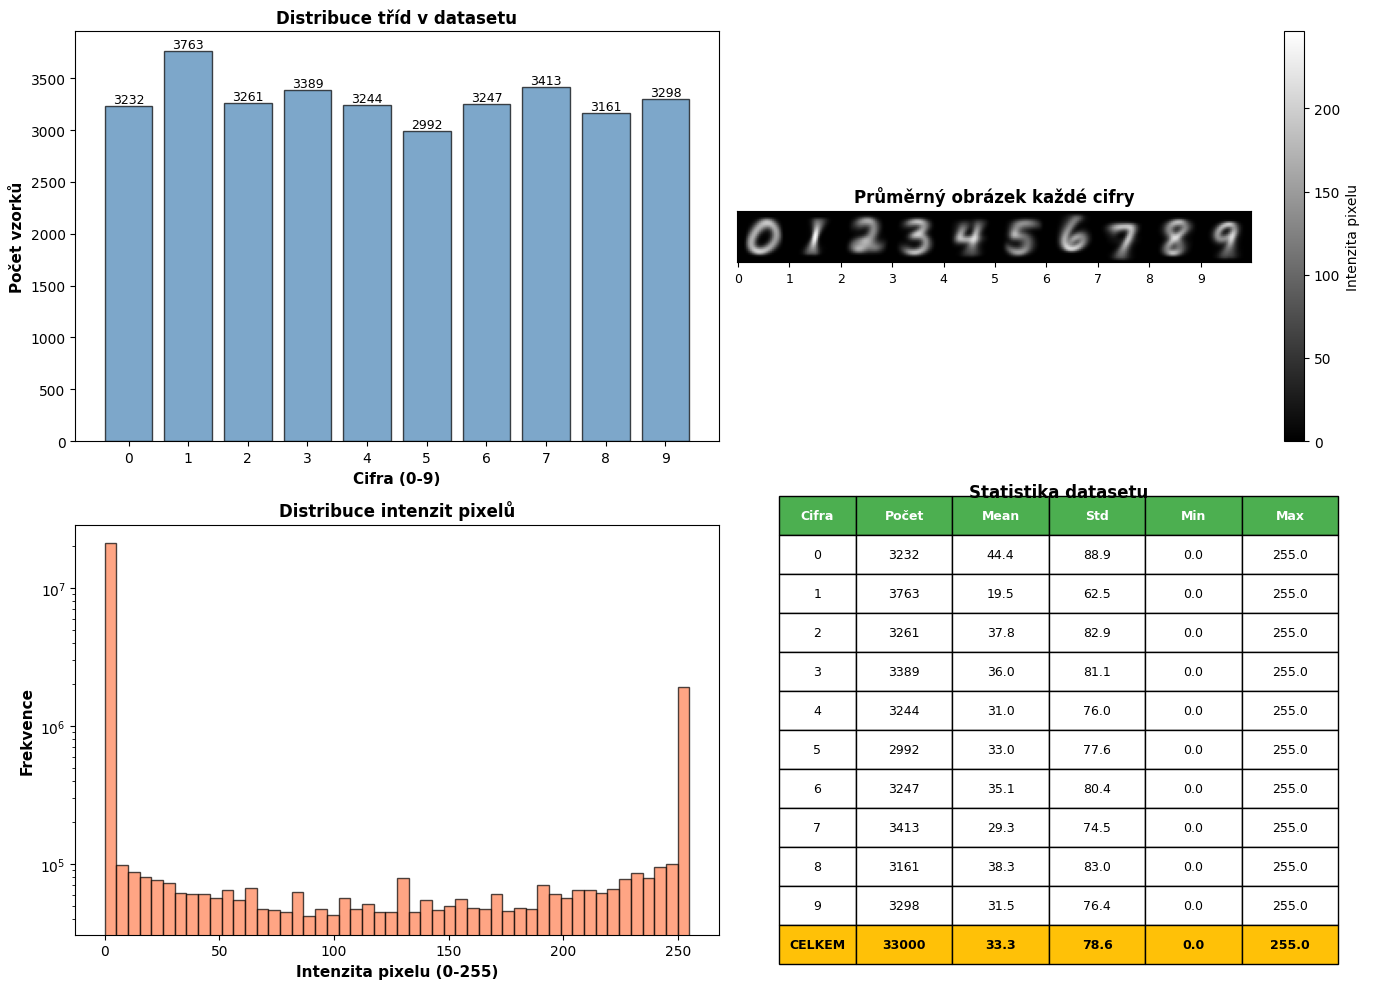


SOUHRN DATASETU
Celkový počet vzorků:    33000
Velikost obrázku:        28 × 28 pixelů (784 features)
Počet tříd:              10 (cifry 0-9)
Průměrná intenzita:      33.35/255
Standardní odchylka:     78.64
Min/Max intenzita:       0/255


In [37]:
# ============================================================================
# EXPLORATIVNÍ ANALÝZA DATASETU
# ============================================================================

print("=" * 80)
print("ANALÝZA DATASETU - MNIST 28x28".center(80))
print("=" * 80)

# 1. DISTRIBUCE TŘÍD
class_counts = np.bincount(y)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graf 1: Distribuce tříd (sloupcový graf)
ax1 = axes[0, 0]
bars = ax1.bar(range(10), class_counts, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Cifra (0-9)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Počet vzorků', fontsize=11, fontweight='bold')
ax1.set_title('Distribuce tříd v datasetu', fontsize=12, fontweight='bold')
ax1.set_xticks(range(10))
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Graf 2: Heatmapa průměrného obrázku pro každou cifru
ax2 = axes[0, 1]
avg_images = np.zeros((10, 28, 28))
for digit in range(10):
    avg_images[digit] = X[y == digit].mean(axis=0).reshape(28, 28)

# Vykreslí jako malou gridu
img_grid = np.hstack([avg_images[i] for i in range(10)])
im = ax2.imshow(img_grid, cmap='gray')
ax2.set_title('Průměrný obrázek každé cifry', fontsize=12, fontweight='bold')
ax2.set_xticks(np.arange(0, 280, 28))
ax2.set_xticklabels(range(10), fontsize=9)
ax2.set_yticks([])
plt.colorbar(im, ax=ax2, label='Intenzita pixelu')

# Graf 3: Histogram intenzit pixelů
ax3 = axes[1, 0]
ax3.hist(X.flatten(), bins=50, color='coral', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Intenzita pixelu (0-255)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frekvence', fontsize=11, fontweight='bold')
ax3.set_title('Distribuce intenzit pixelů', fontsize=12, fontweight='bold')
ax3.set_yscale('log')

# Graf 4: Statistika tabulka
ax4 = axes[1, 1]
ax4.axis('off')

# Vytvoř tabulku
stats_data = []
for digit in range(10):
    digit_data = X[y == digit]
    stats_data.append([
        f'{digit}',
        f'{len(digit_data)}',
        f'{digit_data.mean():.1f}',
        f'{digit_data.std():.1f}',
        f'{digit_data.min():.1f}',
        f'{digit_data.max():.1f}'
    ])

# Přidej řádek pro celkově
overall_stats = [
    'CELKEM',
    f'{len(X)}',
    f'{X.mean():.1f}',
    f'{X.std():.1f}',
    f'{X.min():.1f}',
    f'{X.max():.1f}'
]
stats_data.append(overall_stats)

table = ax4.table(cellText=stats_data,
                  colLabels=['Cifra', 'Počet', 'Mean', 'Std', 'Min', 'Max'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.12, 0.15, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Zbarvit header
for i in range(6):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Zbarvit poslední řádek (celkem)
for i in range(6):
    table[(11, i)].set_facecolor('#FFC107')
    table[(11, i)].set_text_props(weight='bold')

ax4.set_title('Statistika datasetu', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SOUHRN DATASETU")
print("=" * 80)
print(f"Celkový počet vzorků:    {len(X)}")
print(f"Velikost obrázku:        28 × 28 pixelů (784 features)")
print(f"Počet tříd:              10 (cifry 0-9)")
print(f"Průměrná intenzita:      {X.mean():.2f}/255")
print(f"Standardní odchylka:     {X.std():.2f}")
print(f"Min/Max intenzita:       {X.min():.0f}/{X.max():.0f}")
print("=" * 80)

In [38]:
# ============================================================================
# APLIKACE METOD REDUKCE DIMENZIONALITY
# ============================================================================

# 1. PCA - Principal Component Analysis
print("Aplikuji PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Celkem vysvětlené: {pca.explained_variance_ratio_.sum():.2%}\n")

# 2. KPCA - Kernel PCA (RBF kernel)
print("Aplikuji KPCA...")
kpca = KernelPCA(n_components=2, kernel='rbf', random_state=42, n_jobs=-1)
X_kpca = kpca.fit_transform(X_scaled)
print("KPCA hotová\n")

# 3. UMAP
print("Aplikuji UMAP...")
if HAS_UMAP:
    umap_reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = umap_reducer.fit_transform(X_scaled)
    print("UMAP hotová\n")
else:
    print("UMAP není dostupný, přeskakuji...\n")
    X_umap = None

# 4. t-SNE (vždy!)
print("Aplikuji t-SNE...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE hotová\n")

Aplikuji PCA...
PCA explained variance: [0.05828018 0.04120507]
Celkem vysvětlené: 9.95%

Aplikuji KPCA...
KPCA hotová

Aplikuji UMAP...
UMAP hotová

Aplikuji t-SNE...
t-SNE hotová



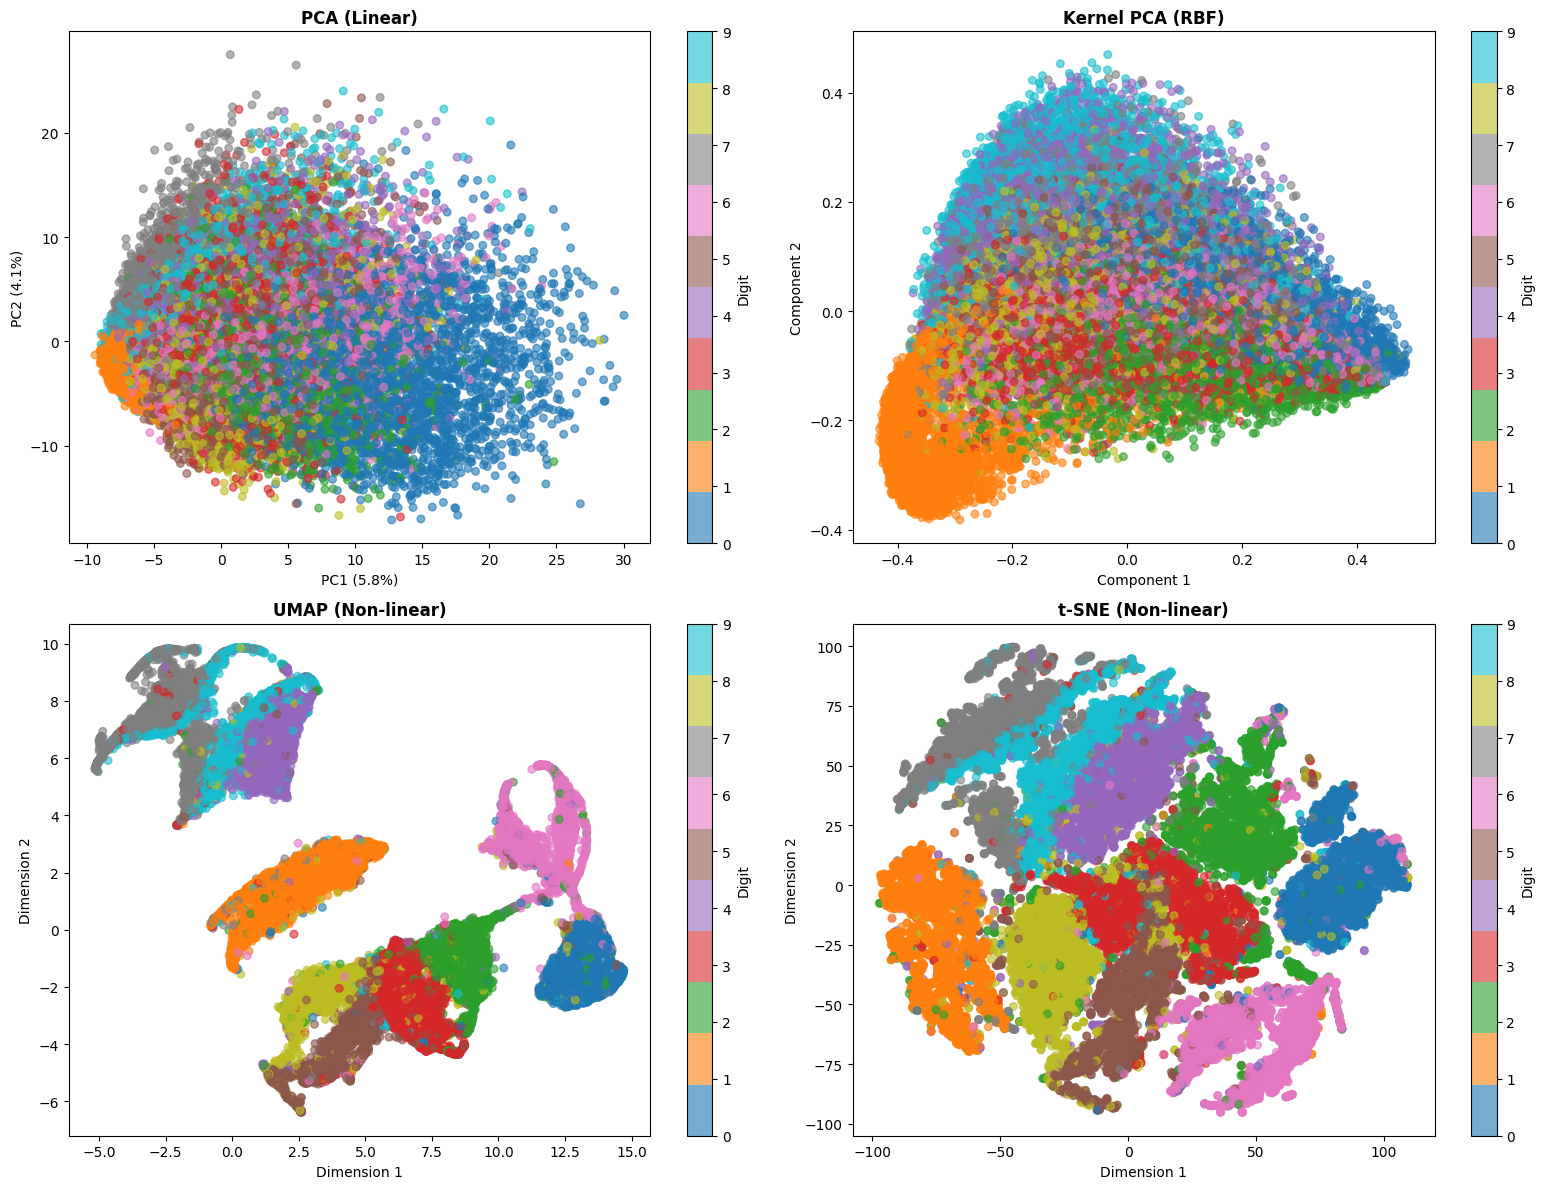

✓ Porovnání grafů hotovo


In [39]:
# ============================================================================
# VIZUALIZACE VÝSLEDKŮ
# ============================================================================

plot_comparison(X_pca, X_kpca, X_umap, X_tsne, y, pca)
print("✓ Porovnání grafů hotovo")

Počítám metriky kvalitaty redukce...

Silhouette Score (higher is better):
  PCA:   -0.0604
  KPCA:  -0.0537
  UMAP:  0.2816
  t-SNE: 0.2090

Souhrnná tabulka:
Metoda  Silhouette Score        Typ
   PCA         -0.060404   Lineární
  KPCA         -0.053707  Kernelová
  UMAP          0.281584 Nelineární
 t-SNE          0.208978 Nelineární


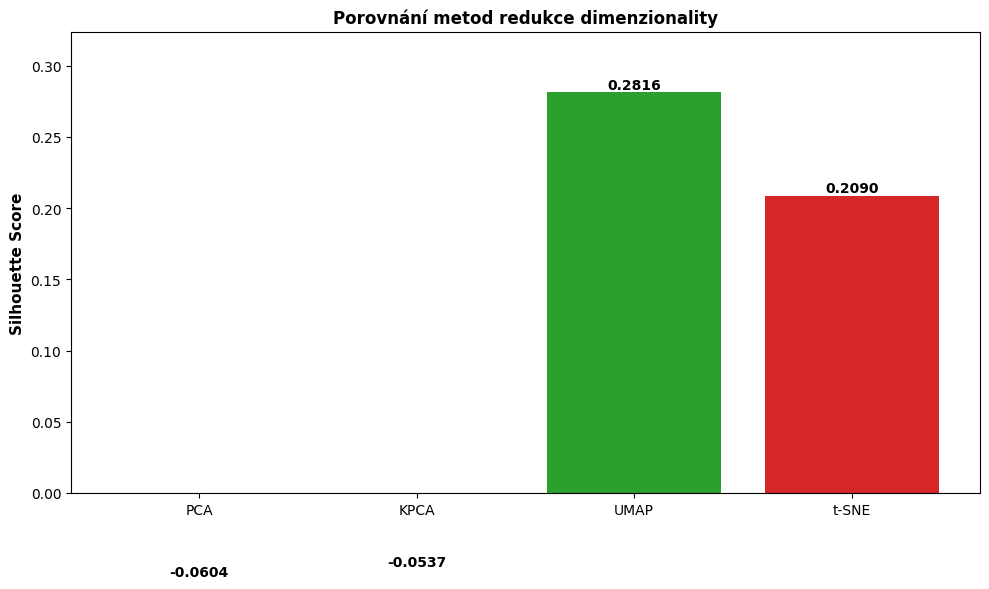

In [40]:
# ============================================================================
# POROVNÁNÍ METOD - SILHOUETTE SCORE
# ============================================================================

from sklearn.metrics import silhouette_score

print("Počítám metriky kvalitaty redukce...\n")

# Silhouette score (čím vyšší, tím lépe rozděleny třídy)
sil_pca = silhouette_score(X_pca, y)
sil_kpca = silhouette_score(X_kpca, y)
sil_umap = silhouette_score(X_umap, y) if X_umap is not None else 0
sil_tsne = silhouette_score(X_tsne, y)

# Zavolej funkcí pro vykreslení
plot_silhouette_scores(sil_pca, sil_kpca, sil_umap, sil_tsne)

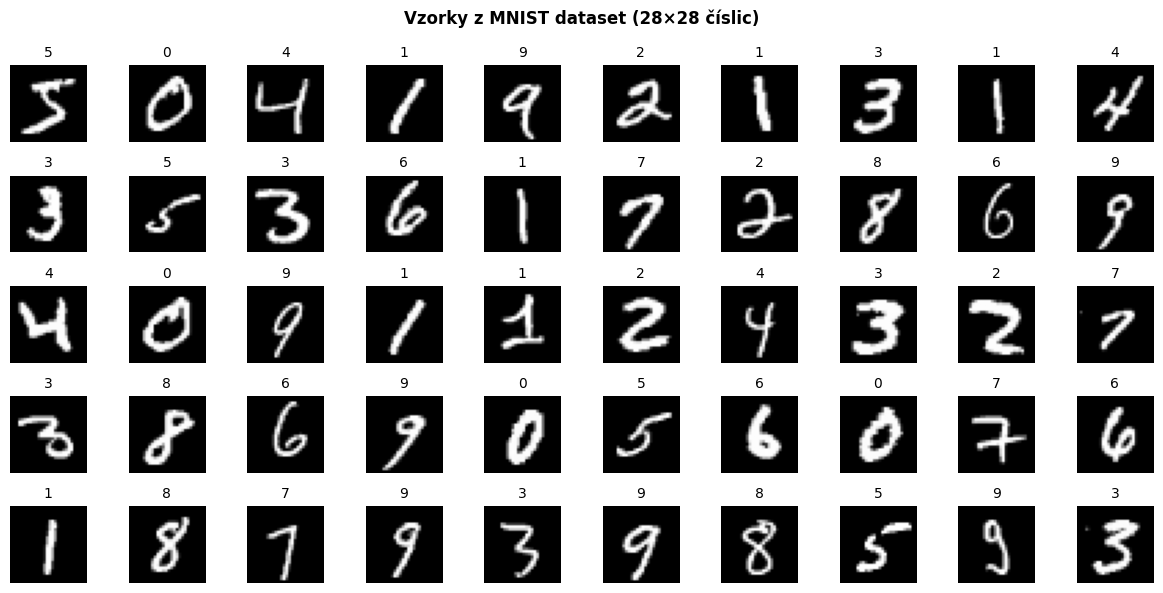

In [ ]:
# ============================================================================
# BONUS: VIZU JEDNOTLIVÝCH ČÍSLIC
# ============================================================================

plot_mnist_samples(X, y, num_samples=50)

In [ ]:
# Zkus tyhle varianty:

# Variant 1: Větší n_neighbors (lepší globální struktura)
um2 = umap.UMAP(n_neighbors=30, min_dist=0.05, random_state=42)
X_umap2 = um2.fit_transform(X_scaled)

# Variant 2: Menší min_dist (těsnější clustery)
um3 = umap.UMAP(n_neighbors=15, min_dist=0.0, random_state=42)
X_umap3 = um3.fit_transform(X_scaled)

# Variant 3: 3D místo 2D (víc prostoru pro separaci)
um4 = umap.UMAP(n_components=3, n_neighbors=20, random_state=42)
X_umap4 = um4.fit_transform(X_scaled)

# Variant 4: Aggressive (nejtvrdší)
um5 = umap.UMAP(n_neighbors=50, min_dist=0.0, metric='cosine', random_state=42)
X_umap5 = um5.fit_transform(X_scaled)

plot_comparison(X_umap2, X_umap3, X_umap4, X_umap5, y)